# Code for doing the different clustering methods, as well as data preprocessing

In this file we run the different methods

### DCEC - Deep Convolutional Embedded Clustering
First load the data

In [10]:
#  Loading the data with all 200 features (for 200x200 data) - alternative loading method

from scipy.io import loadmat
import torch
import numpy as np

filepath = "Input Data\OldAge_combined_run1_400_noZ_clean.mat"
fc_mat = loadmat(filepath)
fc_mat = fc_mat['run1_data']  # Extract the FC1 variable from the loaded .mat file

print(fc_mat.shape)  # Should print (200, 200, N_subjects) for FC1
 # prints (N_subjects, 400, 400) for collected matrices

# fc_mat_inv = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 200, 200)
# fc_mat_inv = fc_mat_inv[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 200, 200)

fc_mat_inv = fc_mat[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 400, 400)
print(fc_mat_inv.shape)  # Should print (N_subjects, 1, 400, 400)

X = torch.from_numpy(fc_mat_inv).float()  # Convert to PyTorch tensor
print("Data shape:", X.shape)  # Should print (N_subjects, 1, 400, 400)

# Expected shape is (Batch size, channels, height, width)

(68, 400, 400)
(68, 1, 400, 400)
Data shape: torch.Size([68, 1, 400, 400])


Define the autoencoder specs for the Convolutional Autoencoder (CAE)

In [11]:
# Config for 400x400 data
from Convolutional_AE import DCECConfig
cfg = DCECConfig(
    name="DCEC_400x400_72_O_subjects_run1",
    n_clusters=3,
    latent_dim=10,
    alpha=1.0,
    gamma=0.1,
    conv_layers_sizes=[1, 32, 64, 128, 256],
    epochs_pretrain=50,
    epochs_dcec=100,
    lr_pretrain=1e-3,
    lr_dcec=1e-3,
    update_interval=8, # Update target distribution every 4 batches, 2 batches in 72 subjects
    tol=4e-2, # 4e-2 = 0.04
    print_interval=10
)


Run the DCEC Model - single run

In [9]:
# Run the DCEC model once for the 200x200 data
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader

from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering
# ----------------------------------------------------------
set_seed(42)

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=3, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO: run the model for multiple cluster numbers and evaluate the clustering performance using Calinski-Harabasz index and silhouette score

model = DCEC(cfg=cfg).to(device)

pretrain_cae(model, dataloader, device, epochs=cfg.epochs_pretrain, lr=cfg.lr_pretrain, print_interval=cfg.print_interval)
y_pred_initial = initialize_cluster_centers(model, dataloader, device)
print("Early cluster centers initialized.", y_pred_initial)

train_dcec(
    model,
    dataloader,
    device,
    gamma=cfg.gamma,
    epochs=cfg.epochs_dcec,
    lr=cfg.lr_dcec,
    update_interval=cfg.update_interval,
    tol=cfg.tol,
    print_interval=cfg.print_interval
    )

q_final, labels = predict_soft_assignments(model, dataloader, device, save=True)
print("Predicted cluster labels:", labels)

# Saving the model
torch.save(model.state_dict(), f"Models\\model_{cfg.name}.pt") 


KeyboardInterrupt: 

Evaluate the clustering from a single run

In [ ]:
# Evaluate clustering performance of a single run
from Evaluate_models import evaluate_single_clustering

triu_idx = np.triu_indices(200, k=1)
fc_mat_transp = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 200, 200)

Features = np.array([
    fc_mat_transp[i][triu_idx] for i in range(fc_mat_transp.shape[0])
]) 
predictions = labels

z = model.z
print("z shape:", z.shape)
print("predictions shape:", predictions.shape)

evaluate_single_clustering(Features, predictions)
evaluate_single_clustering(z, predictions)


z shape: (72, 10)
predictions shape: (72,)

 Scores for the given labels:
Silhouette coefficient: -0.0065830557800347815
Davies-Bouldin score: 5.791408188248332
Calinski-Harabasz score: 1.6109826752774332

 Scores for the given labels:
Silhouette coefficient: 0.7092928290367126
Davies-Bouldin score: 0.4119676234723881
Calinski-Harabasz score: 523.4943903282461


(0.7092928290367126, 0.4119676234723881, 523.4943903282461)

In [ ]:
# Plot the model from one run
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from Evaluate_models import plot_scores, Calculate_clustering_scores_from_folder
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=34, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg.n_clusters = 3  # Set the number of clusters to 3 for the latest model
model = DCEC(cfg=cfg).to(device)
model.load_state_dict(torch.load(f"Models/model_DCEC_200x200_clusters_3.pt"))  #


# Code for visualising the clustering results 
from Convolutional_AE import plot_training_history, plot_clustering, plot_reconstruction

plot_reconstruction(model, dataloader, device)
# plot_training_history(model)
plot_clustering(model, dataloader, device)

results = Calculate_clustering_scores_from_folder(models_dir="Clusters", model_prefix="DCEC_200x200_cluster", labels_tag="_labels_predicted_labels_", middle_layer_tag="_middle_layer_predicted_labels_")
plot_scores(results)




Run the DCEC model multiple times

In [12]:
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering
# ----------------------------------------------------------

set_seed(42)  # Set a fixed random seed for reproducibility

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=34, shuffle=False) # Batch_size 34 gives 2 bacthes for 72 subjects. 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cluster_sizes =  list(range(2, 11)) # Example cluster sizes to evaluate

for n_clusters in cluster_sizes:
    run_cfg = deepcopy(cfg)  # Create a copy of the config for each run
    run_cfg.n_clusters = n_clusters
    
    model = DCEC(cfg=run_cfg).to(device)
    print(f"Running DCEC for cluster {n_clusters} ...")
    pretrain_cae(
        model,
        dataloader,
        device,
        epochs=run_cfg.epochs_pretrain,
        lr=run_cfg.lr_pretrain,
        print_interval=run_cfg.print_interval
    )
    y_pred_initial = initialize_cluster_centers(model, dataloader, device)
    print("Early cluster centers initialized.", y_pred_initial)

    train_dcec(
        model,
        dataloader,
        device,
        gamma=run_cfg.gamma,
        epochs=run_cfg.epochs_dcec,
        lr=run_cfg.lr_dcec,
        update_interval=run_cfg.update_interval,
        tol=run_cfg.tol,
        print_interval=run_cfg.print_interval,
        # y_pred_initial=y_pred_initial
    )

    q_final, labels = predict_soft_assignments(model, dataloader, device, save=True)
    print("Predicted cluster labels:", labels)

    # Saving the model
    torch.save(model.state_dict(), f"Models\\model_{cfg.name}_Cluster_{n_clusters}.pt") 


Running DCEC for cluster 2 ...
[Pretrain] Epoch 001/50 - Recon loss: 0.158208
[Pretrain] Epoch 005/50 - Recon loss: 0.131979
[Pretrain] Epoch 010/50 - Recon loss: 0.102261
[Pretrain] Epoch 015/50 - Recon loss: 0.073879
[Pretrain] Epoch 020/50 - Recon loss: 0.072344
[Pretrain] Epoch 025/50 - Recon loss: 0.070678
[Pretrain] Epoch 030/50 - Recon loss: 0.069292
[Pretrain] Epoch 035/50 - Recon loss: 0.067946
[Pretrain] Epoch 040/50 - Recon loss: 0.066429
[Pretrain] Epoch 045/50 - Recon loss: 0.064641
[Pretrain] Epoch 050/50 - Recon loss: 0.062436
Early cluster centers initialized. [0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0]
[DCEC] Epoch 001/100 - Total: 0.230875, Recon: 0.188970, KL: 0.041904
[DCEC] Epoch 010/100 - Total: 0.076959, Recon: 0.076955, KL: 0.000004
Stopping early: cluster assignments stabilized. Delta: 0.012895763 < Tol: 0.04
Stopped at epoch 16 and batch 2 after 32 updates.
Predicted

Evaluate the models from multiple cluster amounts

In [ ]:
# Print the clustering scores for all the runs 
from Evaluate_models import evaluate_single_clustering, Calculate_clustering_scores_from_folder
import os
import numpy as np

model_prefix = "DCEC_200x200_72_"
labels_tag = "_labels_predicted_labels_"
middle_layer_tag = "_middle_layer_predicted_labels_"

# Load the middle layer and predicted labels from the saved model
# Open the folder "Models"
Calculate_clustering_scores_from_folder(
    model_prefix = model_prefix,
    print_results = True
)

# Silhouett score: Higher is better
# Calinski-Harabasz score: Lower is better
# Davies-Bouldin score: Higher is better
        



 Scores for the given labels:
Silhouette coefficient: 0.7440006497935902
Davies-Bouldin score: 0.39983516064148705
Calinski-Harabasz score: 524.5220128355613
Only one cluster in the provided labels, silhouette coefficient not computed.

 Scores for the given labels:
Silhouette coefficient: 0
Davies-Bouldin score: 0
Calinski-Harabasz score: 0

 Scores for the given labels:
Silhouette coefficient: 0.7092928257118688
Davies-Bouldin score: 0.4119676076573114
Calinski-Harabasz score: 523.4943938602993

 Scores for the given labels:
Silhouette coefficient: 0.6669657882173043
Davies-Bouldin score: 0.41566812642260587
Calinski-Harabasz score: 556.7596040871812

 Scores for the given labels:
Silhouette coefficient: 0.571525566308964
Davies-Bouldin score: 0.6145494205907277
Calinski-Harabasz score: 19.046443913412087

 Scores for the given labels:
Silhouette coefficient: 0.6385777940723618
Davies-Bouldin score: 0.569114950261285
Calinski-Harabasz score: 181.57011567164145

 Scores for the given

{'DCEC_200x200_72_subjects_cluster_10_labels_predicted_labels_.txt': {'silhouette': 0.7440006497935902,
  'davies_bouldin': 0.39983516064148705,
  'calinski_harabasz': 524.5220128355613},
 'DCEC_200x200_72_subjects_cluster_2_labels_predicted_labels_.txt': {'silhouette': 0,
  'davies_bouldin': 0,
  'calinski_harabasz': 0},
 'DCEC_200x200_72_subjects_cluster_3_labels_predicted_labels_.txt': {'silhouette': 0.7092928257118688,
  'davies_bouldin': 0.4119676076573114,
  'calinski_harabasz': 523.4943938602993},
 'DCEC_200x200_72_subjects_cluster_4_labels_predicted_labels_.txt': {'silhouette': 0.6669657882173043,
  'davies_bouldin': 0.41566812642260587,
  'calinski_harabasz': 556.7596040871812},
 'DCEC_200x200_72_subjects_cluster_5_labels_predicted_labels_.txt': {'silhouette': 0.571525566308964,
  'davies_bouldin': 0.6145494205907277,
  'calinski_harabasz': 19.046443913412087},
 'DCEC_200x200_72_subjects_cluster_6_labels_predicted_labels_.txt': {'silhouette': 0.6385777940723618,
  'davies_boul

Only one cluster in the provided labels, silhouette coefficient not computed.
Only one cluster in the provided labels, silhouette coefficient not computed.
Only one cluster in the provided labels, silhouette coefficient not computed.
Only one cluster in the provided labels, silhouette coefficient not computed.
Only one cluster in the provided labels, silhouette coefficient not computed.
Model names: ['DCEC_400x400_72_O_subjects_run1_cluster_10_labels_predicted_labels_.txt', 'DCEC_400x400_72_O_subjects_run1_cluster_2_labels_predicted_labels_.txt', 'DCEC_400x400_72_O_subjects_run1_cluster_3_labels_predicted_labels_.txt', 'DCEC_400x400_72_O_subjects_run1_cluster_4_labels_predicted_labels_.txt', 'DCEC_400x400_72_O_subjects_run1_cluster_5_labels_predicted_labels_.txt', 'DCEC_400x400_72_O_subjects_run1_cluster_6_labels_predicted_labels_.txt', 'DCEC_400x400_72_O_subjects_run1_cluster_7_labels_predicted_labels_.txt', 'DCEC_400x400_72_O_subjects_run1_cluster_8_labels_predicted_labels_.txt', 'DC

c:\Users\oddar\OneDrive - NTNU\Documents\Universitet\Masteroppgåve\Master-Thesis-Autoencoder-and-UMAP-clustering-on-functional-connectivity\Evaluate_models.py:195: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cluster_names, rotation=45, ha='right')


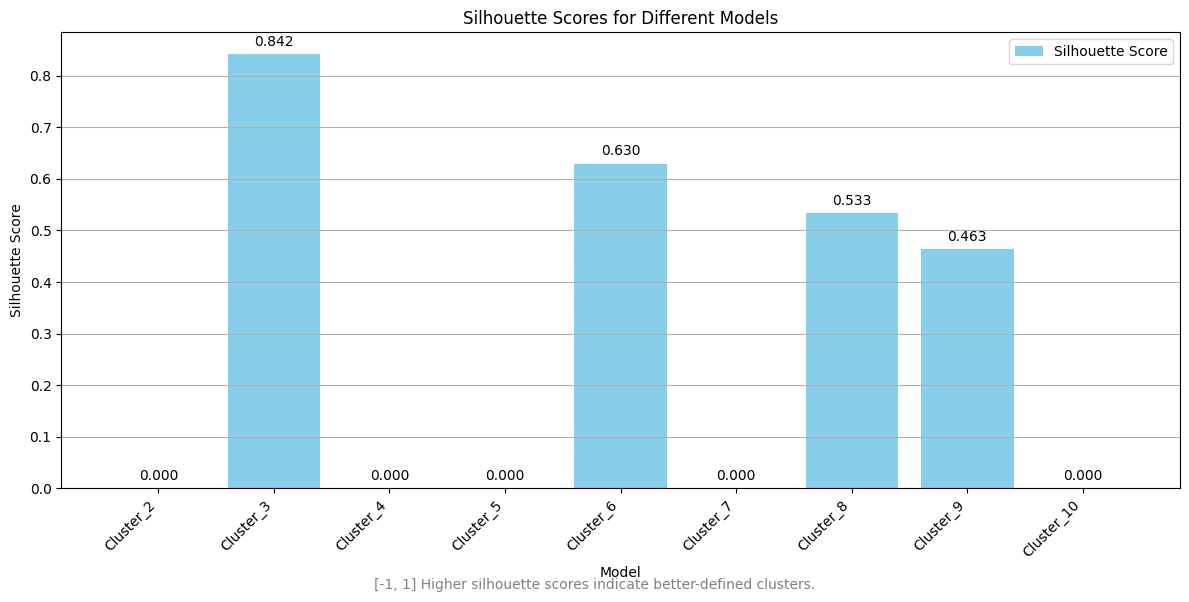

c:\Users\oddar\OneDrive - NTNU\Documents\Universitet\Masteroppgåve\Master-Thesis-Autoencoder-and-UMAP-clustering-on-functional-connectivity\Evaluate_models.py:220: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cluster_names, rotation=45, ha='right')


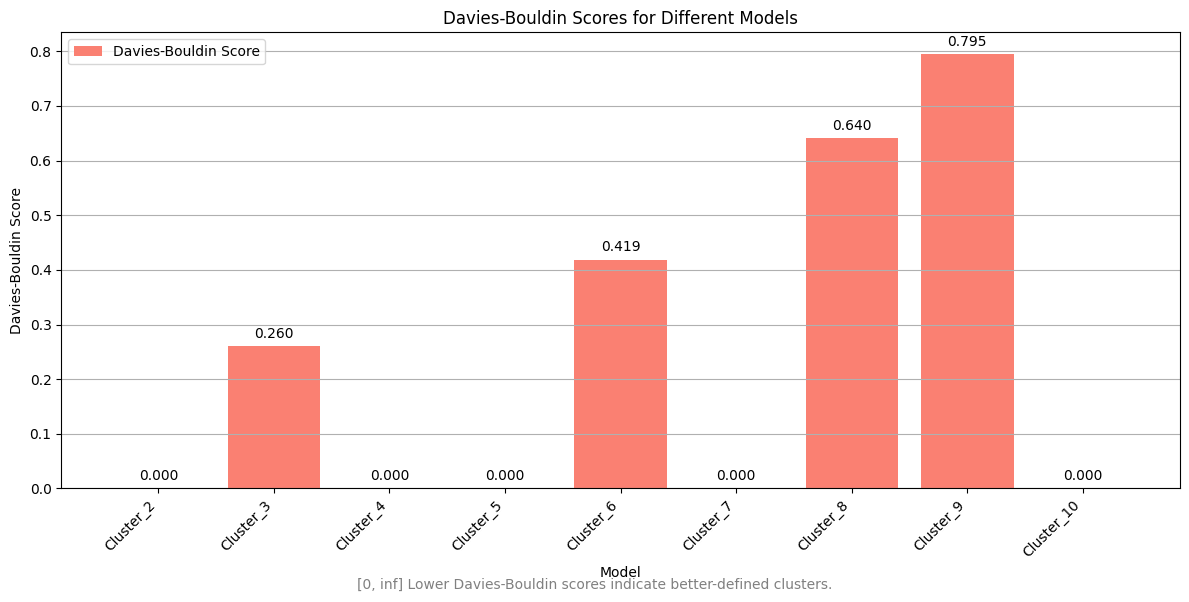

c:\Users\oddar\OneDrive - NTNU\Documents\Universitet\Masteroppgåve\Master-Thesis-Autoencoder-and-UMAP-clustering-on-functional-connectivity\Evaluate_models.py:244: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cluster_names, rotation=45, ha='right')


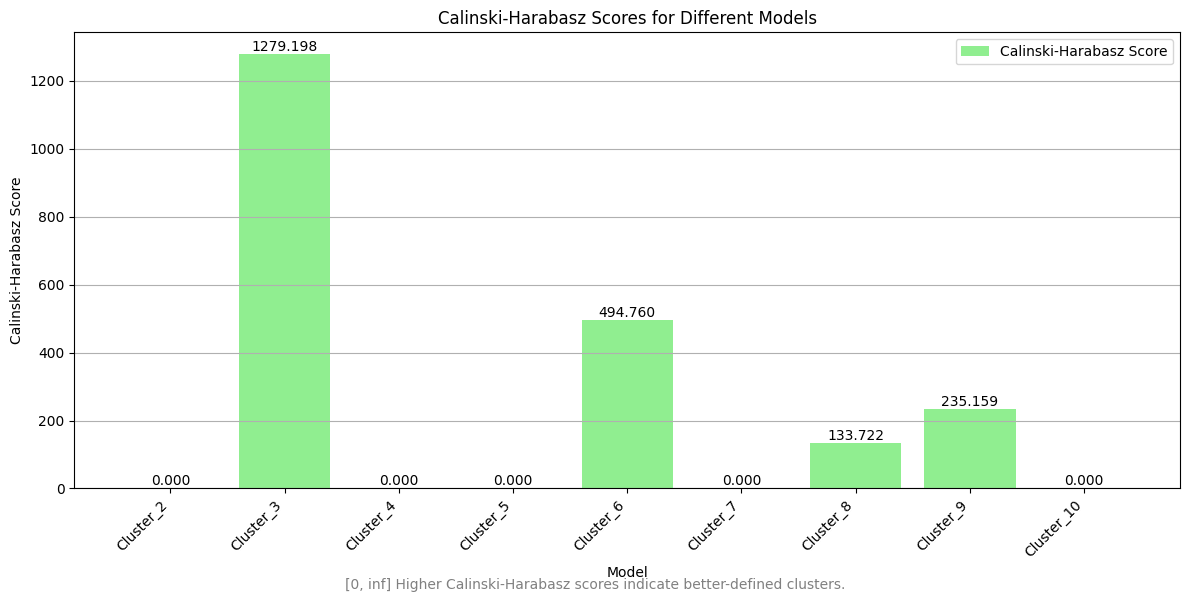


 Evaluating model: model_DCEC_400x400_72_O_subjects_run1_Cluster_10.pt


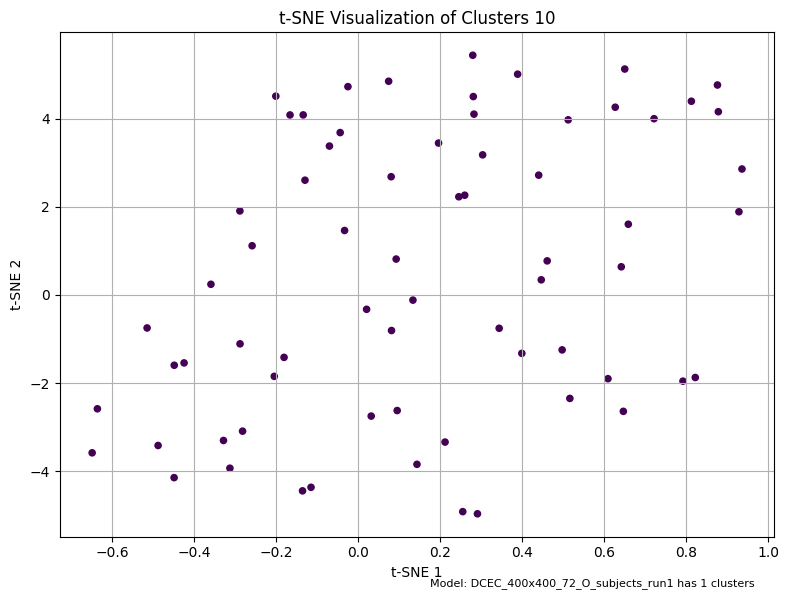


 Evaluating model: model_DCEC_400x400_72_O_subjects_run1_Cluster_2.pt


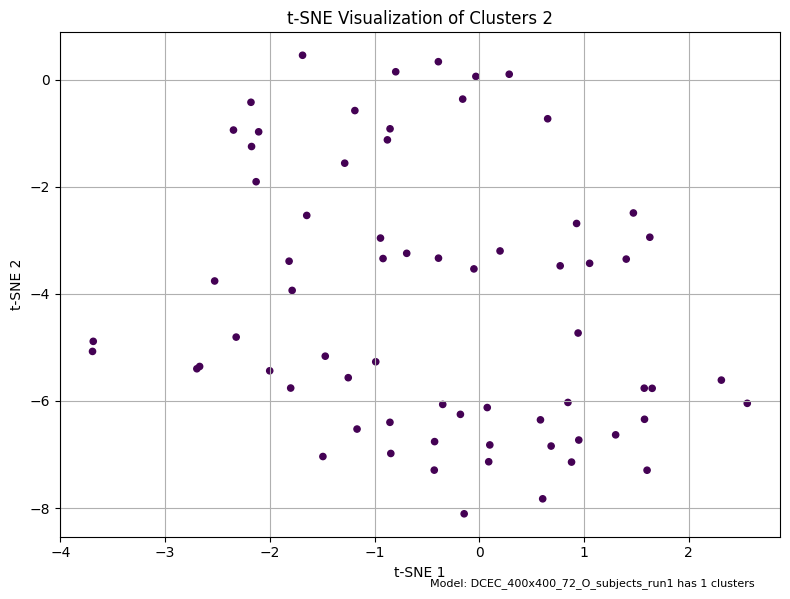


 Evaluating model: model_DCEC_400x400_72_O_subjects_run1_Cluster_3.pt


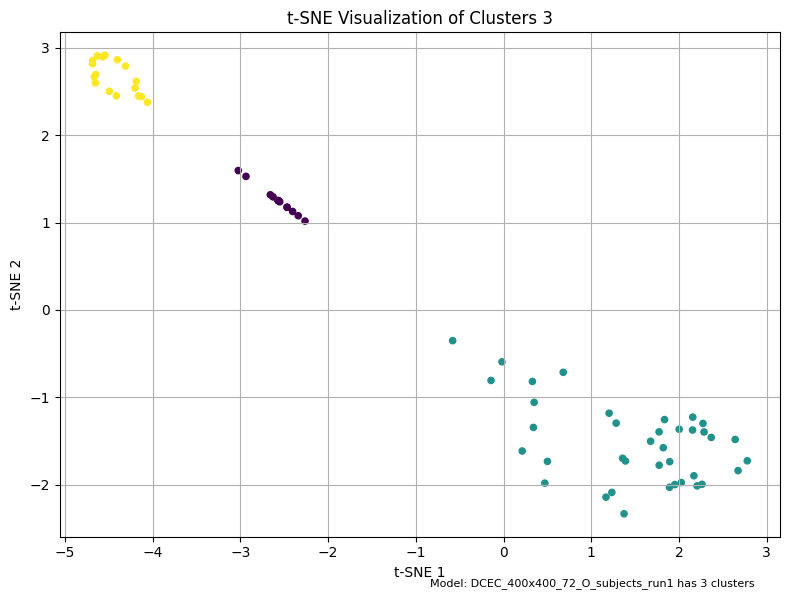


 Evaluating model: model_DCEC_400x400_72_O_subjects_run1_Cluster_4.pt


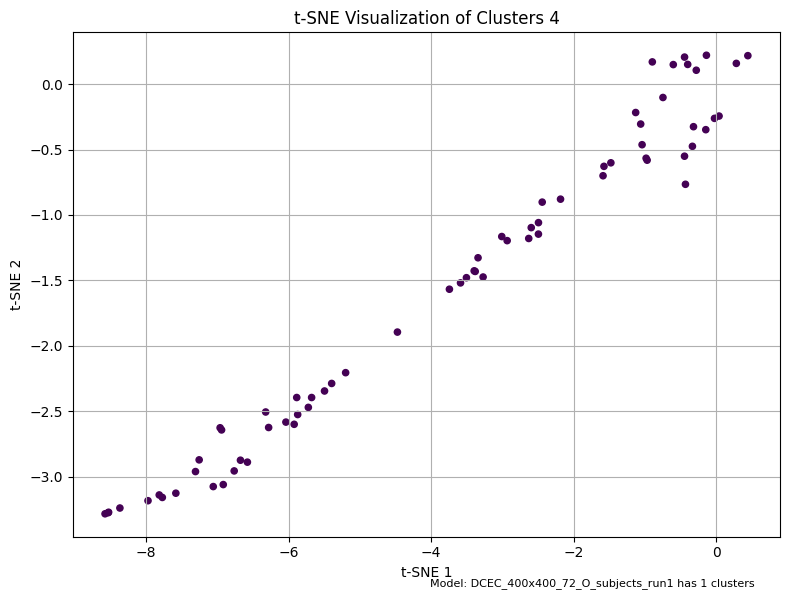


 Evaluating model: model_DCEC_400x400_72_O_subjects_run1_Cluster_5.pt


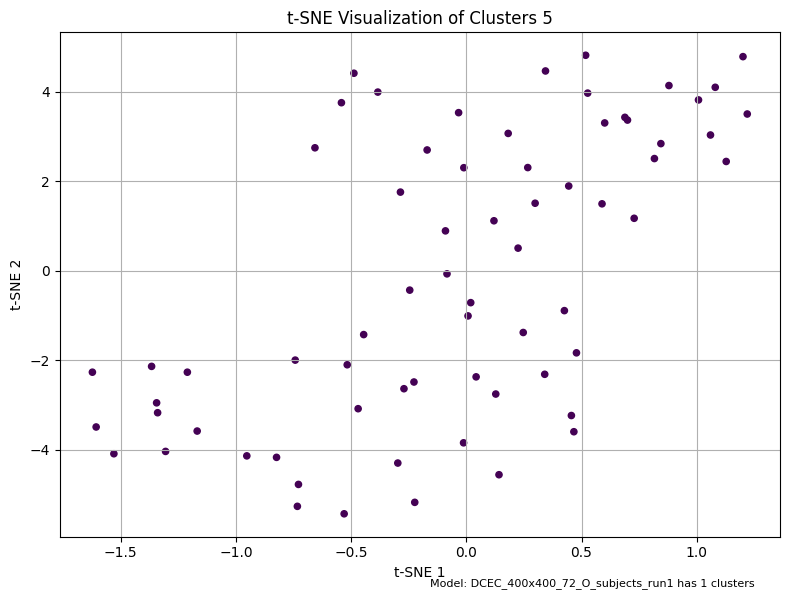


 Evaluating model: model_DCEC_400x400_72_O_subjects_run1_Cluster_6.pt


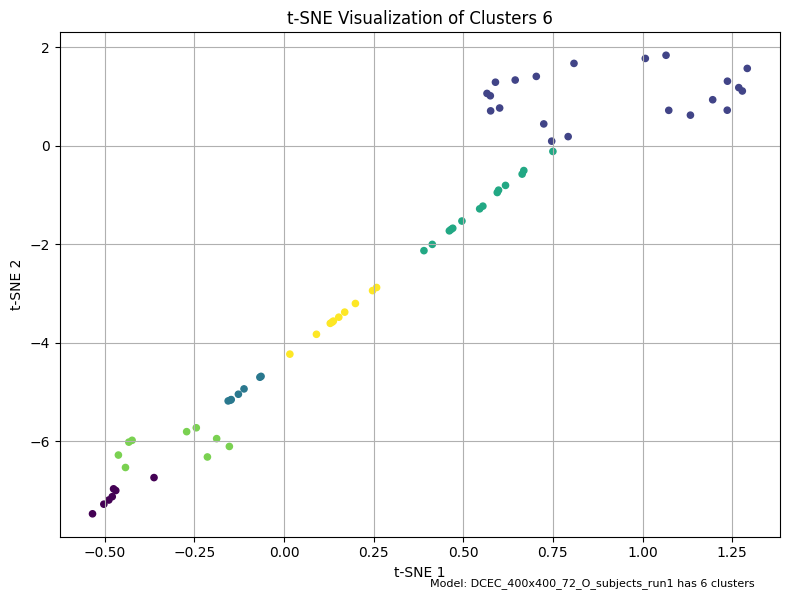


 Evaluating model: model_DCEC_400x400_72_O_subjects_run1_Cluster_7.pt


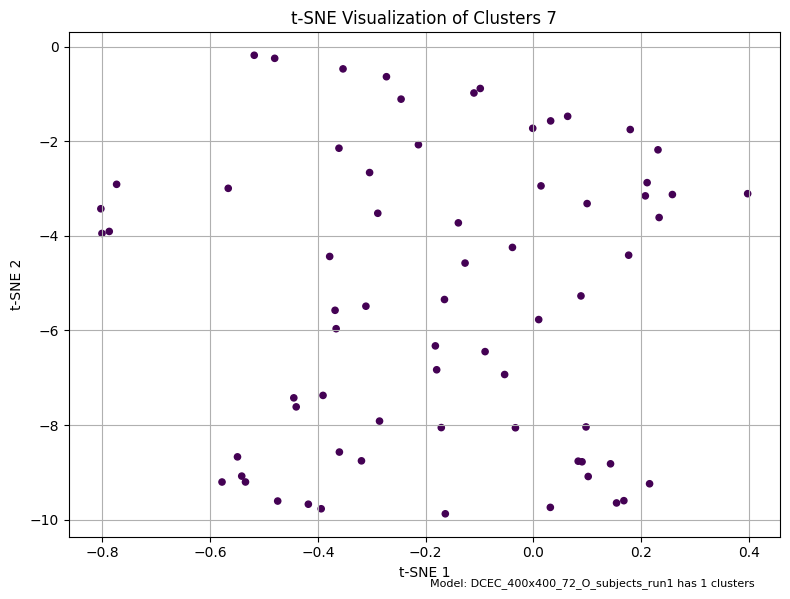


 Evaluating model: model_DCEC_400x400_72_O_subjects_run1_Cluster_8.pt


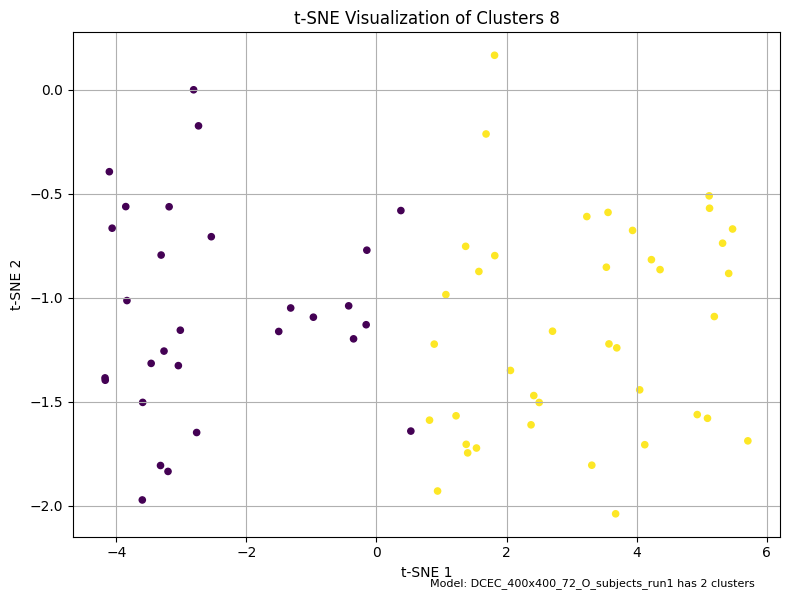


 Evaluating model: model_DCEC_400x400_72_O_subjects_run1_Cluster_9.pt


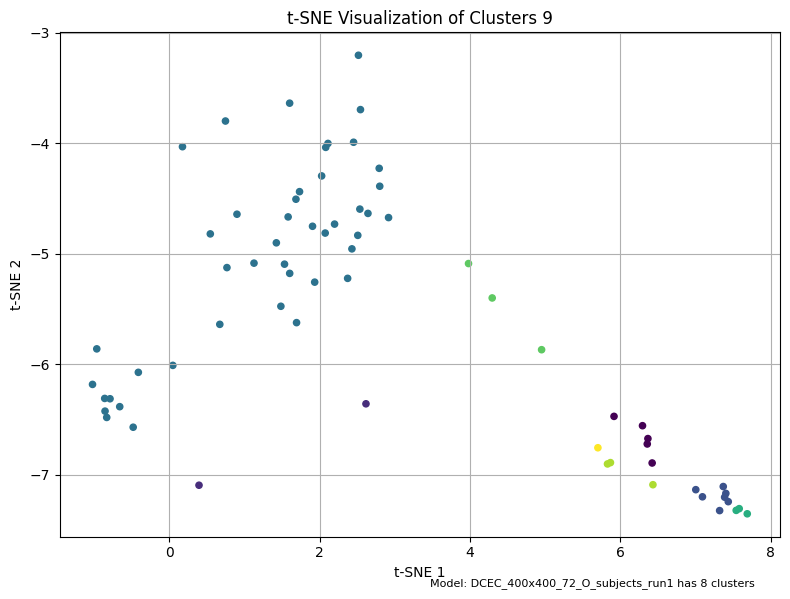

In [13]:
# PLot the results for all the runs
from Evaluate_models import plot_scores, Calculate_clustering_scores_from_folder
from Convolutional_AE import plot_clustering, DCEC
from torch.utils.data import TensorDataset, DataLoader
import os
import torch

results = Calculate_clustering_scores_from_folder(models_dir="Clusters", model_prefix="DCEC_400x400_72_O_subjects_run1_", labels_tag="_labels_predicted_labels_", middle_layer_tag="_middle_layer_predicted_labels_")
plot_scores(results, sort_scores=True, save_path="Figures\\DCEC_400x400_72_O_subjects_run1_clustering")

# Plot the clustering results for the models
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=3, shuffle=False)
for model in os.listdir("Models"):
    if model.startswith("model_DCEC_400x400_72_O_subjects_run1_"): # Only plot the models with the specified prefix
        print(f"\n Evaluating model: {model}")
        cluster_number = model.split("Cluster_")[1].split(".pt")[0]  # Extract the cluster number from the model name
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        cfg.n_clusters = int(cluster_number)  # Set the number of clusters to the extracted number
        temp_model = DCEC(cfg=cfg).to(device)   
        temp_model.load_state_dict(torch.load(f"Models/{model}"))
        
        plot_clustering(temp_model, dataloader, device, save_path =f"Figures\\{model}.png")


### UMAP

In [ ]:
from UMAP import UMAP

### HDBSCAN
Perform HDBSCAN on the data

In [ ]:
from My_HDBSCAN import hdbscan_clustering

hdbscan_clustering(Functional_connectivity_matrix=Functional_connectivity_matrix, save_labels=True)